# 確率予測

識別とは違って確率を正確に予測したい場合

## Calibration

**Probabilistic calibration** あるいは単に **calibration** （較正）は、

> 確率分類モデルの予測確率の『正しさ』を評価すること

または

> その評価に基づいて予測モデルを改善するための手法

の意味で使われる。後者は **recalibration（再較正）** とも呼ばれる。


## 評価手法の分類

[calibration hierarchy](https://pubmed.ncbi.nlm.nih.gov/26772608/) などの分類

mean calibrationほど弱い基準

1. **Mean calibration**：データ全体での平均の予測確率と実際の比率が一致しているかどうか $\mathbb{E}[p] = \mathbb{E}[y]$
2. **Weak calibration**：予測確率が全体として極端すぎたり控えめすぎたりしないか → 予測確率値の分布がロジスティック分布に合致しているか。
3. **Moderate calibration**：同じ予測確率を出した集団は、観測値の比率もその確率に一致するか $P(Y \mid \hat{p}=p)=p$
4. **Strong calibration**：任意の特徴量$X$で条件つけた分布が予測と一致するか $P(Y \mid X)=\hat{p}(X)$


### 1. Mean calibration

例えば二値分類において、モデルが全データに対して平均 0.20 のpositiveの確率を出していて、実際のpositiveの割合も 20% なら **mean calibration は満たす**、という考え方

$$
\frac{1}{n}\sum_i \hat{p}_i \approx \frac{1}{n}\sum_i y_i
$$

しかし全体平均しか見ていないので正確性は欠ける

### 2. Weak calibration

Mean Calibrationより少し強い基準だが、ロジスティック回帰に依存した考え方。医療分野では使うらしい。

予測確率値の分布がロジスティック分布に合致しているかを確認するというもの。  
具体的には、推定したロジスティック回帰モデルの線形予測子に対して線形回帰した際に、定数項$\alpha$がゼロで、傾き$\beta$が1であるかどうかで評価する  

$$
\operatorname{logit}(P(Y=1))=\alpha+\beta \cdot \operatorname{logit}(\hat{p})
$$


### 3. Moderate calibration

予測確率でビニングし、それぞれを期待値で見て一致しているかどうか



#### Calibration Plot / reliability diagram

予測確率の正しさを評価するためのplot。

横軸に予測確率をとり、縦軸に経験確率（サンプル上の比率）をとるplot。  
予測確率をいくつかのbinに区切り、bin内のサンプルでの比率から経験確率を計算する。

scikit-learnの`calibration_curve()` で簡単に計算できる

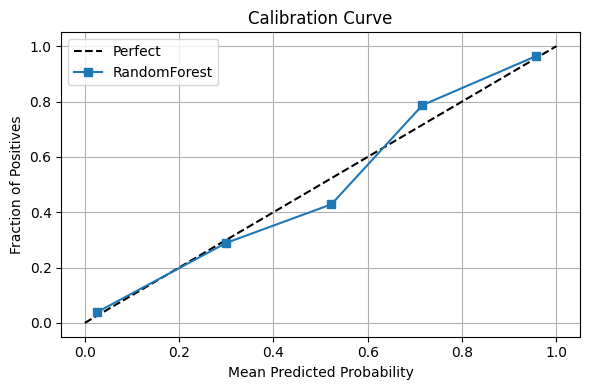

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

# データ生成・分割
X, y = make_classification(n_samples=2000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 学習・予測
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
prob = rf.predict_proba(X_test)[:, 1]

# Calibration Curve
frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=5)

plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.plot(mean_pred, frac_pos, 's-', label='RandomForest')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


:::{info}

scikit-learn documentation [Probability Calibration curves](https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html) ではNaive Bayesがかなり歪んだCalibration Curveを出力すること（そしてrecalibrationにより補正できること）が示されている

:::

#### 新しいReliability Diagram

[Bröcker & Smith (2007)](https://journals.ametsoc.org/view/journals/wefo/22/3/waf993_1.xml) や [Vaicenavicius et al., 2019](https://proceedings.mlr.press/v89/vaicenavicius19a.html) で横向きにしたcalibration plotが提案されている

大まかに再現したのが以下のコード

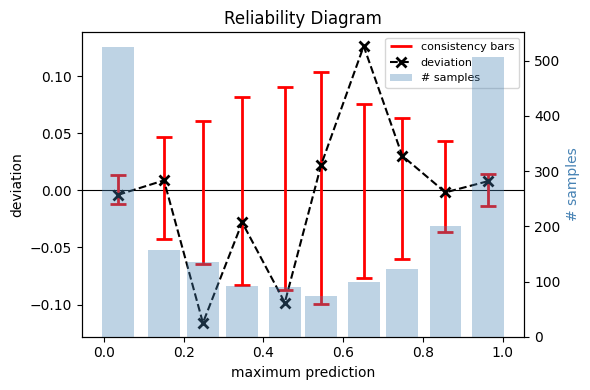

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# データ生成・学習
X, y = make_classification(n_samples=5000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
model = LogisticRegression(random_state=42).fit(X_train, y_train)
prob = model.predict_proba(X_test)[:, 1]

# ビンごとにdeviation・consistency barsを計算
bin_edges = np.linspace(0, 1, 11)
means, devs, counts, lows, highs = [], [], [], [], []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (prob >= lo) & (prob < hi)
    if mask.sum() == 0:
        continue
    p, yt = prob[mask], y_test[mask]
    dev = yt.mean() - p.mean()
    rs = [np.random.binomial(1, p).mean() - p.mean() for _ in range(1000)]

    means.append(p.mean())
    devs.append(dev)
    counts.append(mask.sum())
    lows.append(np.percentile(rs, 5))
    highs.append(np.percentile(rs, 95))

means, devs, counts, lows, highs = map(np.array, [means, devs, counts, lows, highs])

# プロット
fig, ax = plt.subplots(figsize=(6, 4))
ax2 = ax.twinx()

ax2.bar(means, counts, width=0.08, color='steelblue', alpha=0.35, label='# samples')
ax2.set_ylabel('# samples', color='steelblue')

ax.axhline(0, color='black', linewidth=0.8)
ax.vlines(means, lows, highs, colors='red', linewidth=2, label='consistency bars')
ax.hlines(lows,  means - 0.02, means + 0.02, colors='red', linewidth=2)
ax.hlines(highs, means - 0.02, means + 0.02, colors='red', linewidth=2)
ax.plot(means, devs, 'x--', color='black', markersize=7, markeredgewidth=2, label='deviation')

ax.set_xlabel('maximum prediction')
ax.set_ylabel('deviation')
ax.set_title('Reliability Diagram')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.show()

#### Expected Calibration Error (ECE)

期待較正誤差 (Expected Calibration Error, ECE) は [Naeini, Cooper, and Hauskrecht (2015)](https://pubmed.ncbi.nlm.nih.gov/25927013/) によって提案された指標で、binごとの実測比率と平均予測確率の平均絶対誤差。

例えば二値分類だとして、陽性クラスの予測確率を $\hat{p}_i$、ラベルを $y_i \in \{0,1\}$ とする。  
予測確率を $M$ 個のビン $B_1,\dots,B_M$ に分けたとき、ECEは次のように定義される。

$$
\mathrm{ECE} := \sum_{m=1}^{M}
\frac{|B_m|}{n}
\left| \frac{1}{|B_m|} \sum_{i \in B_m} y_i - \frac{1}{|B_m|} \sum_{i \in B_m} \hat{p}_i \right|
$$

なお、ECEの派生が様々ある

- Maximum Calibration Error (MCE)
- Confidence-Calibrated ECE (CC-ECE)

## 参考文献

- [機械学習のカリブレーションとビジネスの関係 〜ローンのパーソナライゼーション | gihyo.jp](https://gihyo.jp/article/2023/03/machine-learning-calibration-and-business)
- [分類モデルの確率カリブレーションの話が全く普及してないので雑多にまとめる - ill-identified diary](https://ill-identified.hatenablog.com/entry/2026/06/27/012530)
    - 非常によいまとめ
- [Vaicenavicius, J., Widmann, D., Andersson, C., Lindsten, F., Roll, J., & Schön, T. (2019, April). Evaluating model calibration in classification. In The 22nd international conference on artificial intelligence and statistics (pp. 3459-3467). PMLR.](https://proceedings.mlr.press/v89/vaicenavicius19a.html)